<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/DeepLearning/DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implement single neuron using numpy

This section focuses on implementing a basic single neuron using the NumPy library, which is a foundational component in neural networks. It covers the core logic of a neuron, including weighted sums, bias, and a sigmoid activation function.

In [ ]:
# Import the NumPy library for numerical operations, essential for array manipulations and mathematical functions.
import numpy as np

In [ ]:
def single_neuron(inputs, weights=None, bias=None):
  # This function simulates a single neuron, computing a weighted sum of inputs and applying a sigmoid activation.

  # Initialize weights if they are not provided by the caller. Random values are generated and scaled.
  if weights is None:
    weights = np.random.randn(len(inputs)) * 0.01
  else:
    weights = np.array(weights) # Ensure weights are a NumPy array for consistent operations.

  # Initialize bias if it is not provided. Default to 0 if not specified.
  if bias is None:
    bias=0
  else:
    bias = bias

  # Calculate the weighted sum of inputs (dot product) and add the bias term. This is often called the 'z-value' or pre-activation.
  z = np.matmul(weights, inputs) + bias
  # Apply the sigmoid activation function to the z-value. This squashes the output to a range between 0 and 1.
  y = 1/(1+np.exp(-z))
  return y

In [ ]:
def touch_or_not(inputs):
  # This function uses the output of the single neuron to make a binary decision: 'touch' or 'Dont touch'.

  # Get the output (y) from the single neuron function for the given inputs.
  y = single_neuron(inputs)
  # Based on the neuron's output, if y is 0.5 or greater, it suggests 'touch', otherwise 'Dont touch'.
  if y >= 0.5:
    print("touch")
  else:
    print("Dont touch")
  return y

In [ ]:
# Define input features for a scenario where something is 'hot_unknown'.
# 'temperature' represents how hot an object is (e.g., 0.9 for very hot).
temperature = 0.9
# 'familiarity' represents how familiar one is with the object (e.g., 0.2 for not very familiar).
familiarity = 0.2
hot_unknown = [temperature, familiarity]
# Call the decision function with these inputs to see the neuron's prediction.
touch_or_not(hot_unknown)

touch


np.float64(0.5013394657902831)

In [ ]:
# Define input features for a scenario involving 'hot_coffee'.
# 'temperature' is moderately high (0.6).
temperature = 0.6
# 'familiarity' is high (0.8), implying prior experience with coffee.
familiarity = 0.8
hot_coffee = [temperature, familiarity]
# Call the decision function to determine if it should be touched.
touch_or_not(hot_coffee)

touch


np.float64(0.5048371654896056)

In [ ]:
# Define input features for a 'cold_coffee' scenario.
# 'temperature' is low (0.2).
temperature = 0.2
# 'familiarity' is high (0.9).
familiarity = 0.9
cold_coffee = [temperature, familiarity]
# Call the decision function with these inputs.
touch_or_not(cold_coffee)

touch


np.float64(0.5019978113763759)

# Multiclass NN

This section introduces concepts for a multi-class neural network, expanding beyond the single neuron's binary classification. It includes functions for softmax activation and cross-entropy loss, which are crucial for handling multiple output classes.

In [ ]:
def softmax(z):
  # The softmax function converts a vector of numbers into a probability distribution.
  # It's commonly used as the activation function for the output layer in multi-class classification problems.

  # Calculate the exponentiated values of the input array z.
  exp_z = np.exp(z)
  # Sum along axis 1 to normalize probabilities for each sample independently.
  # keepdims=True ensures that the sum retains the same number of dimensions as exp_z, which is important for broadcasting.
  return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
# Define the number of features for input data.
n_features=2
# Define the number of classes for classification.
n_classes=3
# Define the number of samples for the dummy dataset.
n_samples =10

# Initialize weight matrix W with random values, scaled by 0.01 to keep initial values small.
# The shape is (n_features, n_classes) as each feature connects to each class output.
W = np.random.randn(n_features, n_classes) * 0.01
# Initialize bias vector b with zeros. The shape is (1, n_classes) to allow broadcasting across samples.
b = np.zeros((1, n_classes))

# Generate a dummy input feature matrix X with random values, scaled by 5.
# The shape is (n_samples, n_features).
X = np.random.randn(n_samples, n_features) * 5
# Display the generated input features.
X

array([[-15.61969467,  -4.36755   ],
       [ -5.25462438,   2.79673828],
       [ -1.69110602,  -2.2691461 ],
       [ -0.42096277,  -5.80801398],
       [ -2.70412234,  -7.52323734],
       [ -9.35828372,   3.50008698],
       [ -3.63722256,   1.00117388],
       [  7.04133065,   2.98509349],
       [ -5.62912626,   0.65233431],
       [  0.60383289,   5.18211986]])

In [ ]:
# Generate dummy true labels (y_true) for the samples.
# np.random.randint(0, 3, n_samples) generates n_samples integers, each being 0, 1, or 2 (representing the classes).
y_true = np.random.randint(0, 3, n_samples)
# Display the generated true labels.
y_true

array([1, 0, 2, 1, 1, 0, 1, 2, 0, 2])

In [ ]:
# Calculate the pre-activation values (Z) for the multi-class network.
# This involves a matrix multiplication of the input features (X) by the weight matrix (W), and then adding the bias vector (b).
# This is the linear transformation part of a neural network layer: Z = XW + b.
Z = np.dot(X, W) + b
# Display the calculated pre-activation values.
Z

array([[-0.00455359,  0.00363501, -0.16107521],
       [-0.02125213,  0.04824762, -0.04498434],
       [ 0.00781054, -0.01940701, -0.0213143 ],
       [ 0.02618144, -0.06262674, -0.01661667],
       [ 0.03049352, -0.07396517, -0.04248431],
       [-0.03100405,  0.06960421, -0.08330986],
       [-0.01038978,  0.02309332, -0.03315435],
       [-0.00264481,  0.00956311,  0.07480467],
       [-0.01193259,  0.02585114, -0.05324649],
       [-0.02299848,  0.05512125,  0.01704195]])

#Prediction

In [ ]:
# Apply the softmax activation function to the pre-activation values (Z) to get predicted probabilities (y_pred).
# The softmax function converts the raw scores (Z) into a probability distribution over the classes.
y_pred = softmax(Z)
# Display the predicted probabilities.
y_pred

array([[0.34924307, 0.35211463, 0.2986423 ],
       [0.32802814, 0.35163691, 0.32033495],
       [0.33962261, 0.33050358, 0.32987381],
       [0.34805297, 0.31847581, 0.33347122],
       [0.35330278, 0.31825938, 0.32843784],
       [0.32734489, 0.36199217, 0.31066294],
       [0.33205574, 0.34336223, 0.32458203],
       [0.32333052, 0.32730191, 0.34936757],
       [0.33355186, 0.34639582, 0.32005232],
       [0.32029673, 0.34632151, 0.33338176]])

#Loss calculation

In [ ]:
# Display the true labels to compare with the predicted probabilities.
y_true

array([1, 0, 2, 1, 1, 0, 1, 2, 0, 2])

In [ ]:
# Get the number of classes, which was defined earlier as 'n_classes'.
num_classes = n_classes
# Get the number of samples from the length of the true labels array.
num_samples_true = len(y_true)

# Create an empty NumPy array for one-hot encoding, initialized with zeros.
# Its shape is (number of samples, number of classes).
one_hot_y_true = np.zeros((num_samples_true, num_classes))
# For each sample, set the element corresponding to its true class to 1.
# np.arange(num_samples_true) creates an array [0, 1, ..., num_samples_true-1] for row indices.
# y_true provides the column indices (the true class labels).
one_hot_y_true[np.arange(num_samples_true), y_true] = 1

# Print the resulting one-hot encoded true labels.
print("One-hot encoded y_true:\n", one_hot_y_true)

One-hot encoded y_true:
 [[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [ ]:
# Calculate the element-wise product of the one-hot encoded true labels and the natural logarithm of the predicted probabilities.
# This is an intermediate step in calculating the cross-entropy loss.
(one_hot_y_true * np.log(y_pred))

array([[-0.        , -1.04379852, -0.        ],
       [-1.11465589, -0.        , -0.        ],
       [-0.        , -0.        , -1.10904508],
       [-0.        , -1.14420877, -0.        ],
       [-0.        , -1.14488855, -0.        ],
       [-1.11674095, -0.        , -0.        ],
       [-0.        , -1.06896933, -0.        ],
       [-0.        , -0.        , -1.05163071],
       [-1.09795691, -0.        , -0.        ],
       [-0.        , -0.        , -1.09846701]])

In [ ]:
# Sum all the elements from the product calculated in the previous step.
# This is another intermediate step for cross-entropy loss, summing the relevant log probabilities.
np.sum(one_hot_y_true * np.log(y_pred))

np.float64(-10.990361723250608)

In [ ]:
# Define a small epsilon value to prevent taking the logarithm of zero, which would result in NaN or infinity.
epsilon = 1e-10 # Small value to prevent log(0)
# Calculate the cross-entropy loss.
# It's the negative sum of the element-wise product of one-hot encoded true labels and the logarithm of predicted probabilities (with epsilon).
# The sum is then averaged by the number of samples.
loss = -np.sum(one_hot_y_true * np.log(y_pred + epsilon)) / num_samples_true
# Print the calculated cross-entropy loss.
print("Cross-entropy loss:", loss)

Cross-entropy loss: 1.099036172024769


#Backpropogation

#Tensor operation using tensorflow


In [ ]:
import tensorflow as tf # Import the TensorFlow library, which is a powerful open-source machine learning framework.

In [ ]:
tf.__version__ # Display the current version of TensorFlow being used.

'2.20.0'

In [ ]:
tf.config.list_physical_devices('GPU') # List all available physical GPU devices detected by TensorFlow.

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
tf.config.list_physical_devices('CPU') # List all available physical CPU devices detected by TensorFlow.

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [ ]:
tf.config.list_physical_devices('GPU') # List all available physical GPU devices detected by TensorFlow. (Repeated for emphasis or re-check)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
a= tf.constant([[1,2,3],[4,5,6]]) # Create a TensorFlow constant tensor named 'a' with a 2x3 matrix of integers.
a # Display the created tensor.

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)>

In [ ]:
a.shape # Get the shape (dimensions) of the tensor 'a'.

TensorShape([2, 3])

In [ ]:
a.dtype # Get the data type of the elements in tensor 'a'.

tf.int32

In [ ]:
tf.rank(a).numpy() # Get the rank (number of dimensions) of tensor 'a' and convert it to a NumPy scalar.

np.int32(2)

In [ ]:
tf.size(a).numpy() # Get the total number of elements in tensor 'a' and convert it to a NumPy scalar.

np.int32(6)

In [ ]:
tf.eye(2,3) # Create an identity matrix-like tensor with 2 rows and 3 columns, filled with zeros and ones on the diagonal.

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 0., 0.],
       [0., 1., 0.]], dtype=float32)>

In [ ]:
a =tf.zeros([3,4]) # Create a TensorFlow tensor named 'a' with all elements initialized to zero, with shape 3x4.
a # Display the created tensor.

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

In [ ]:
a =tf.ones([3,4]) # Create a TensorFlow tensor named 'a' with all elements initialized to one, with shape 3x4.
a # Display the created tensor.

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]], dtype=float32)>

In [ ]:
b = tf.constant([[1,2,3,4],[1,2,3,4],[1,2,3,4]], dtype=tf.float32) # Create a TensorFlow constant tensor named 'b' with a 3x4 matrix of floats.
b # Display the created tensor.

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[1., 2., 3., 4.],
       [1., 2., 3., 4.],
       [1., 2., 3., 4.]], dtype=float32)>

In [ ]:
c = tf.add(a,b) # Perform element-wise addition of tensors 'a' and 'b', storing the result in 'c'.
c # Display the resulting tensor.

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[2., 3., 4., 5.],
       [2., 3., 4., 5.],
       [2., 3., 4., 5.]], dtype=float32)>

In [ ]:
tf.reduce_mean(c).numpy() # Calculate the mean of all elements in tensor 'c' and convert it to a NumPy scalar.

np.float32(3.5)

In [ ]:
tf.reduce_mean(c, axis=1).numpy() # Calculate the mean of elements along axis 1 (rows) of tensor 'c' and convert to NumPy array.

array([3.5, 3.5, 3.5], dtype=float32)

In [ ]:
tf.reduce_mean(c, axis=0).numpy() # Calculate the mean of elements along axis 0 (columns) of tensor 'c' and convert to NumPy array.

array([2., 3., 4., 5.], dtype=float32)

In [ ]:
tf.reduce_max(c) # Find the maximum value among all elements in tensor 'c'.

<tf.Tensor: shape=(), dtype=float32, numpy=5.0>

In [ ]:
tf.reduce_max(c, axis=1) # Find the maximum value along axis 1 (rows) of tensor 'c'.

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([5., 5., 5.], dtype=float32)>

In [ ]:
x = tf.random.normal([2,3]) # Create a TensorFlow tensor 'x' with random values from a normal distribution, with shape 2x3.
x # Display the created tensor.

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 0.9401358 ,  0.52212036,  0.8535509 ],
       [-0.435831  , -1.015507  ,  1.6798263 ]], dtype=float32)>

In [ ]:
y = tf.random.normal([3,2]) # Create a TensorFlow tensor 'y' with random values from a normal distribution, with shape 3x2.
y # Display the created tensor.

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 0.84334296,  0.18712562],
       [ 1.4630002 ,  0.42490613],
       [-0.39119673,  1.0450993 ]], dtype=float32)>

In [ ]:
tf.matmul(x,y) # Perform matrix multiplication of tensors 'x' and 'y'. (2x3 * 3x2 = 2x2)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 1.2228128,  1.2898211],
       [-2.5103846,  1.2425349]], dtype=float32)>

In [ ]:
tf.matmul(y,x) # Perform matrix multiplication of tensors 'y' and 'x'. (3x2 * 2x3 = 3x3)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 0.71130174,  0.25029916,  1.0341747 ],
       [ 1.1902316 ,  0.33236703,  1.9625136 ],
       [-0.8232647 , -1.2655574 ,  1.4216789 ]], dtype=float32)>

In [ ]:
x.shape # Get the shape of tensor 'x'.

TensorShape([2, 3])

In [ ]:
tf.reshape(x,[3,2]) # Reshape tensor 'x' into a new tensor with shape 3x2. Note: This requires the number of elements to remain the same.

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 0.9401358 ,  0.52212036],
       [ 0.8535509 , -0.435831  ],
       [-1.015507  ,  1.6798263 ]], dtype=float32)>

In [ ]:
tf.reshape(c,-1) # Reshape tensor 'c' into a 1D tensor (flattening it). The -1 infers the dimension size.

<tf.Tensor: shape=(12,), dtype=float32, numpy=array([2., 3., 4., 5., 2., 3., 4., 5., 2., 3., 4., 5.], dtype=float32)>

In [ ]:
tf.reshape(c,[2,-1]) # Reshape tensor 'c' into a 2D tensor with 2 rows, automatically inferring the number of columns.

<tf.Tensor: shape=(2, 6), dtype=float32, numpy=
array([[2., 3., 4., 5., 2., 3.],
       [4., 5., 2., 3., 4., 5.]], dtype=float32)>

In [ ]:
c.shape # Get the shape of tensor 'c'.

TensorShape([3, 4])

In [ ]:
d = tf.expand_dims(c,axis=0) # Add a new dimension (axis) at position 0 to tensor 'c', making it (1, 3, 4).
d # Display the new tensor 'd'.

<tf.Tensor: shape=(1, 3, 4), dtype=float32, numpy=
array([[[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]]], dtype=float32)>

In [ ]:
tf.squeeze(d) # Remove dimensions of size 1 from tensor 'd'. This will revert 'd' back to (3, 4).

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[2., 3., 4., 5.],
       [2., 3., 4., 5.],
       [2., 3., 4., 5.]], dtype=float32)>

In [ ]:
c.shape # Get the shape of tensor 'c' again to confirm it hasn't changed.

TensorShape([3, 4])

In [ ]:
e= tf.Variable([1,2,3]) # Create a TensorFlow Variable named 'e' with initial integer values. Variables are mutable tensors used in model parameters.
e # Display the Variable.

<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

In [ ]:
tf.one_hot(e,3) # Perform one-hot encoding on tensor 'e'. Each integer in 'e' will be converted into a vector of length 3, with a '1' at the index corresponding to the integer value.

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 0.]], dtype=float32)>

In [ ]:
img = tf.random.uniform([128, 128, 3], 0., 1.) # Create a TensorFlow tensor named 'img' representing an image, with random uniform pixel values between 0 and 1. The shape (128, 128, 3) corresponds to height, width, and 3 color channels (RGB).

In [ ]:
img # Display the generated image tensor.

<tf.Tensor: shape=(128, 128, 3), dtype=float32, numpy=
array([[[0.8933927 , 0.7431222 , 0.07179618],
        [0.5167787 , 0.04994106, 0.95303345],
        [0.8716645 , 0.8012605 , 0.19880235],
        ...,
        [0.48280227, 0.49455488, 0.5379833 ],
        [0.76185775, 0.79125977, 0.9612771 ],
        [0.49665666, 0.72642374, 0.07958865]],

       [[0.0661577 , 0.900519  , 0.8187305 ],
        [0.5766903 , 0.515888  , 0.37633622],
        [0.36655903, 0.30338967, 0.9413657 ],
        ...,
        [0.9318545 , 0.10600543, 0.32695746],
        [0.06344473, 0.656621  , 0.13446188],
        [0.6322104 , 0.74201655, 0.84829164]],

       [[0.73701847, 0.74219024, 0.18771291],
        [0.28183234, 0.54375315, 0.19834828],
        [0.648877  , 0.39695287, 0.96955407],
        ...,
        [0.2193811 , 0.25409496, 0.27253032],
        [0.59659946, 0.7945399 , 0.6121206 ],
        [0.87252283, 0.22031283, 0.9125204 ]],

       ...,

       [[0.18434739, 0.5204768 , 0.34050715],
        [0.36

In [ ]:
A = tf.random.uniform([3, 2], minval=0., maxval=1.) # Create a TensorFlow tensor 'A' with random uniform values between 0 and 1, with shape 3x2.

In [ ]:
A # Display the created tensor 'A'.

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[0.4514221 , 0.6912761 ],
       [0.07812631, 0.27216685],
       [0.81381774, 0.17279232]], dtype=float32)>

In [ ]:
with tf.device('/CPU:0'): # Explicitly specify that the following operations should run on the CPU.
  import tensorflow as tf # Re-import TensorFlow (good practice if device scope creates a new context, though often not strictly necessary).
  import time # Import the time module to measure execution time.

  def normal_fn(x):
      for _ in range(1000):
          x = tf.math.sqrt(x) # Apply element-wise square root 1000 times in eager mode.
      return x

  @tf.function # Decorator to compile the function into a TensorFlow graph for potentially faster execution.
  def graph_fn(x):
      for _ in range(1000):
          x = tf.math.sqrt(x) # Apply element-wise square root 1000 times within the compiled graph.
      return x

  x = tf.random.uniform([1000,1000]) # Create a large tensor for benchmarking.

  # Measure normal (eager) execution
  start = time.time()
  normal_fn(x)
  print("Normal:", time.time()-start) # Print time taken for eager execution.

  # Measure graph (tf.function) execution
  start = time.time()
  graph_fn(x)
  print("Graph:", time.time()-start) # Print time taken for graph execution. Note: First call includes graph compilation time.

Normal: 0.6240735054016113
Graph: 1.0151028633117676


In [ ]:
# Simulating one layer: 4 samples, 3 features each
X = tf.constant([[1, 2, 3],
                 [4, 5, 6],
                 [7, 8, 9],
                 [10, 11, 12]], dtype=tf.float32)  # shape (4, 3) # Define input features X as a TensorFlow constant tensor.


# Weight matrix: 3 input features → 2 neurons
W = tf.constant([[0.1, 0.2],
                 [0.3, 0.4],
                 [0.5, 0.6]], dtype=tf.float32)     # shape (3, 2) # Define the weight matrix W for the layer.

# Bias: one per output neuron
b = tf.constant([0.01, 0.02], dtype=tf.float32)     # shape (2,) # Define the bias vector b for the layer.


# Forward pass through one layer
z = tf.matmul(X, W) + b    # matrix multiply + broadcast add # Calculate the weighted sum of inputs and add bias (linear transformation).
print("Layer output shape:", z.shape)  # (4, 2) — 4 samples, 2 neurons # Print the shape of the output tensor.
print("Layer output:\n", z.numpy()) # Print the numerical values of the layer's output.

Layer output shape: (4, 2)
Layer output:
 [[ 2.21       2.8200002]
 [ 4.9100003  6.42     ]
 [ 7.6100006 10.02     ]
 [10.31      13.620001 ]]


#Training Mnist image data using Keras

In [ ]:
import tensorflow as tf # Import the TensorFlow library.
from tensorflow import keras # Import Keras from TensorFlow for building and training neural networks.
from tensorflow.keras import layers # Import the layers module from Keras for defining model layers.

# 1. Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data() # Load the MNIST handwritten digits dataset, splitting it into training and testing sets for features (X) and labels (y).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.dtype # Check the data type of the elements in the X_train (training features) NumPy array.

dtype('uint8')

In [ ]:
type(X_train) # Check the type of the X_train object.

numpy.ndarray

In [ ]:
X_train.shape # Get the shape (dimensions) of the X_train dataset (number of images, height, width).

(60000, 28, 28)

In [ ]:
X_train[0, 0:28, :]#=X_train[0] # Display the first image (index 0) from the X_train dataset, specifically all rows and columns.

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [ ]:
X_train_flattend = tf.reshape(X_train,[X_train.shape[0],-1]) # Flatten each image in X_train from a 2D matrix (28x28) into a 1D vector (784 pixels). The -1 infers the last dimension.
X_train_flattend.shape # Display the new shape of the flattened training data.

TensorShape([60000, 784])

In [ ]:
X_test_flattend = tf.reshape(X_test,[X_test.shape[0],-1]) # Flatten each image in X_test similarly to X_train.

In [ ]:
type(X_test_flattend) # Check the type of the flattened X_test object.

tensorflow.python.framework.ops.EagerTensor

In [ ]:
X_test_norm = X_test_flattend/255 # Normalize the pixel values of the flattened X_test data by dividing by 255, scaling them to the range [0, 1].
X_train_norm = X_train_flattend/255 # Normalize the pixel values of the flattened X_train data.
print(f'Max-{tf.reduce_max(X_test_norm)} Min- {tf.reduce_min(X_test_norm)}') # Print the maximum and minimum pixel values in the normalized test data to verify normalization.

Max-1.0 Min- 0.0


In [ ]:
X_test_norm.dtype # Check the data type of the normalized X_test data.

tf.float32

In [ ]:
type(y_train) # Check the type of the y_train (training labels) object.

numpy.ndarray

In [ ]:
y_train.shape # Get the shape (dimensions) of the y_train dataset (number of labels).

(60000,)

In [ ]:
import numpy as np
unique_values, counts = np.unique(y_train, return_counts=True) # Find the unique values in y_train and count their occurrences.
print(f"Unique values in y_train: {unique_values}") # Print the unique digit labels.
print(f"Counts of each unique value: {counts}") # Print the frequency of each digit.

Unique values in y_train: [0 1 2 3 4 5 6 7 8 9]
Counts of each unique value: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [ ]:
y_train_onehot = tf.one_hot(y_train,depth=10) # Convert integer labels in y_train to one-hot encoded vectors of depth 10 (for 10 classes).
y_test_onehot = tf.one_hot(y_test,depth=10) # Convert integer labels in y_test to one-hot encoded vectors.
y_train_onehot.shape # Display the shape of the one-hot encoded training labels.

TensorShape([60000, 10])

In [ ]:
keras_model = keras.Sequential([ # Create a sequential Keras model.
    layers.Dense(256, activation='relu'), # Add a dense (fully connected) layer with 256 units and ReLU activation.
    layers.Dense(128, activation='relu'), # Add another dense layer with 128 units and ReLU activation.
    layers.Dense(64, activation='relu'), # Add another dense layer with 64 units and ReLU activation.
    layers.Dense(10, activation='softmax') # Add the output dense layer with 10 units (for 10 classes) and softmax activation for probability distribution.
])

# 4. Compile the model
k:keras_model.compile(
    optimizer='adam', # Configure the model for training with the Adam optimizer.
    loss='categorical_crossentropy', # Set the loss function to categorical cross-entropy, suitable for multi-class classification with one-hot encoded labels.
    metrics=['accuracy'] # Specify 'accuracy' as the metric to monitor during training.
)

In [ ]:
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 256 # Keeping the same batch size as PyTorch example # Define the batch size for training.
epochs = 10 # Keeping the same number of epochs # Define the number of training epochs.

# Explicitly build the model to ensure variables are created before training
keras_model.build(input_shape=(None, X_train_norm.shape[1]))

history = keras_model.fit(
    X_train_norm, y_train_onehot,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1, # Show progress bar # Train the model using the training data and labels.
    validation_data=(X_test_norm, y_test_onehot) # Provide validation data to evaluate the model's performance on unseen data after each epoch.
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9013 - loss: 0.3424 - val_accuracy: 0.9546 - val_loss: 0.1510
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9640 - loss: 0.1212 - val_accuracy: 0.9701 - val_loss: 0.0954
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9759 - loss: 0.0778 - val_accuracy: 0.9715 - val_loss: 0.0870
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9827 - loss: 0.0569 - val_accuracy: 0.9758 - val_loss: 0.0743
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9872 - loss: 0.0411 - val_accuracy: 0.9777 - val_loss: 0.0695
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9905 - loss: 0.0310 - val_accuracy: 0.9780 - val_loss: 0.0713
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9923 - loss: 0.0238 - val_accuracy: 0.9762 - val_loss: 0.0793
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9943 - loss: 0.0189 - val_accuracy: 0

In [ ]:

# 6. Evaluate the model
loss, accuracy = keras_model.evaluate(X_test_norm, y_test_onehot, verbose=0) # Evaluate the trained model on the test data to get final loss and accuracy.
print(f'\nKeras Test Loss: {loss:.4f}') # Print the test loss.
print(f'Keras Test Accuracy: {accuracy*100:.2f}%') # Print the test accuracy as a percentage.


Keras Test Loss: 0.0712
Keras Test Accuracy: 97.95%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
Original Label: 6
Predicted Label: 6
Prediction Probabilities: [8.5059237e-06 3.1730902e-09 1.8261552e-11 4.3754891e-12 1.2947356e-11
 3.9444960e-05 9.9995208e-01 7.3480692e-12 3.0591620e-11 8.6837021e-10]


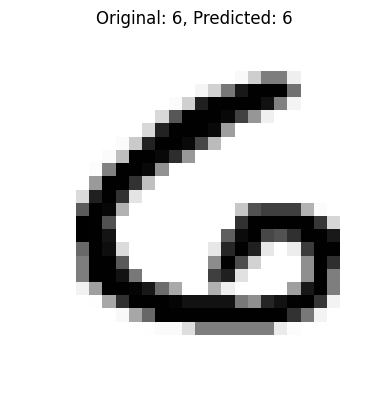

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a random index from the test set
random_index = np.random.randint(0, len(X_test_norm))

# Get the original image and label
original_image_flat = X_test_norm[random_index]
original_label = y_test[random_index]

# Reshape the image for prediction (add batch dimension)
# The model expects input shape (batch_size, num_features)
image_for_prediction = tf.expand_dims(original_image_flat, axis=0)

# Make a prediction using the trained model
predictions = keras_model.predict(image_for_prediction)

# Get the predicted label (class with highest probability)
predicted_label = np.argmax(predictions[0])

print(f"Original Label: {original_label}")
print(f"Predicted Label: {predicted_label}")
print(f"Prediction Probabilities: {predictions[0]}")

# Display the original image (optional, for visual verification)
plt.imshow(X_test[random_index], cmap=plt.cm.binary)
plt.title(f"Original: {original_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

#IMDB Data NN in Keras. Text Processing.

In [ ]:
VOCAB_SIZE=10000 # Define the maximum number of words to keep in the vocabulary, based on word frequency.
MAX_LEN=200 # Define the maximum length of movie reviews (in words) after padding/truncation.
EMBEDDING_DIM = 32 # Define the dimensionality of the word embeddings.
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE) # Load the IMDB dataset, which consists of movie reviews and their sentiment labels (0 for negative, 1 for positive). `num_words` restricts the vocabulary size.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
type(X_train_raw) # Check the data type of `X_train_raw`, which contains the training movie review sequences.

numpy.ndarray

In [ ]:
X_train_raw.shape # Get the shape of `X_train_raw`, showing the number of training samples.

(25000,)

In [ ]:
num_words = [len(i) for i in X_train_raw] # Calculate the length (number of words) for each review in the raw training dataset.

In [ ]:
np.max(num_words) # Find the maximum length among all training reviews.

np.int64(2494)

In [ ]:
np.min(num_words) # Find the minimum length among all training reviews.

np.int64(11)

In [ ]:
np.mean(num_words) # Calculate the average length of all training reviews.

np.float64(238.71364)

In [ ]:
np.percentile(num_words, 98) # Calculate the 98th percentile of review lengths, indicating that 98% of reviews are shorter than this length.

np.float64(799.0200000000004)

In [ ]:
count = 0
for i in num_words:
  if i <200:
    count+=1
print(f'Percentage of reviews fully covered with 200 lenght {count/len(num_words)*100}') # Calculate and print the percentage of reviews that are shorter than the defined MAX_LEN (200 words).

Percentage of reviews fully covered with 200 lenght 56.976000000000006


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import the `pad_sequences` utility for standardizing sequence lengths.
X_test_padded = pad_sequences(X_test_raw, maxlen=MAX_LEN, padding='pre') # Pad or truncate test sequences to `MAX_LEN`, adding padding at the beginning.
X_train_padded = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='pre') # Pad or truncate training sequences to `MAX_LEN`, adding padding at the beginning.

In [ ]:
type(X_test_padded) # Check the data type of the padded test data.

numpy.ndarray

In [ ]:
X_test_padded.shape # Get the shape of the padded test data, which should now be (num_samples, MAX_LEN).

(25000, 200)

In [ ]:
X_train_padded.shape # Get the shape of the padded training data.

(25000, 200)

In [ ]:
y_train # Display the training labels (sentiment for each review).

array([1, 0, 0, ..., 0, 1, 0])

In [ ]:
np.size(y_train) # Get the total number of training labels.

25000

In [ ]:
np.size(y_test) # Get the total number of test labels.

25000

In [ ]:
model_flatten = keras.Sequential([ # Initialize a Keras Sequential model, which is a linear stack of layers.
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN), # Embedding layer: Converts integer-encoded words into dense vectors of fixed size (EMBEDDING_DIM).
    keras.layers.Flatten(), # Flatten layer: Converts the 2D output of the Embedding layer (batch, sequence, features) into a 1D feature vector for each sample.
    keras.layers.Dense(64, activation='relu'), # Dense layer: A fully connected layer with 64 units and ReLU activation for learning non-linear patterns.
    keras.layers.Dense(1, activation='sigmoid')   # Output layer: A single dense unit with sigmoid activation for binary classification (sentiment: positive/negative).
])

model_flatten.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Compile the model: Configure it for training with the Adam optimizer, binary cross-entropy loss (suitable for binary classification), and accuracy as a metric.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_flatten.summary() # Display a summary of the `model_flatten` architecture, including layer names, output shapes, and the number of parameters.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_flatten = model_flatten.fit( # Train the `model_flatten` using the padded training data and labels.
    X_train_padded, y_train,
    epochs=5, # Train for 5 epochs (one full pass over the training data).
    batch_size=128, # Process data in batches of 128 samples.
    validation_split=0.2, # Use 20% of the training data as a validation set to monitor performance during training.
    verbose=1 # Show a progress bar during training.
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7229 - loss: 0.5094 - val_accuracy: 0.8582 - val_loss: 0.3303
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9329 - loss: 0.1813 - val_accuracy: 0.8646 - val_loss: 0.3308
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9885 - loss: 0.0495 - val_accuracy: 0.8514 - val_loss: 0.4036
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9979 - loss: 0.0136 - val_accuracy: 0.8572 - val_loss: 0.4299
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9998 - loss: 0.0037 - val_accuracy: 0.8626 - val_loss: 0.4496


In [ ]:
model_gap = keras.Sequential([ # Initialize a Keras Sequential model for the Global Average Pooling (GAP) approach.
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN), # Embedding layer: Converts integer-encoded words into dense vectors.
    keras.layers.GlobalAveragePooling1D(), # GlobalAveragePooling1D layer: Computes the average of the word embeddings across the sequence length, outputting a single vector for each review. This helps reduce dimensionality and can mitigate overfitting.
    keras.layers.Dense(64, activation='relu'), # Dense layer: A fully connected layer with 64 units and ReLU activation.
    keras.layers.Dense(1, activation='sigmoid') # Output layer: A single dense unit with sigmoid activation for binary classification.
])

model_gap.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Compile the GAP model with the Adam optimizer, binary cross-entropy loss, and accuracy.

In [ ]:
model_gap.summary() # Display a summary of the `model_gap` architecture.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gap = model_gap.fit( # Train the `model_gap` using the padded training data and labels.
    X_train_padded, y_train,
    epochs=5, # Train for 5 epochs.
    batch_size=128, # Process data in batches of 128 samples.
    validation_split=0.2, # Use 20% of the training data for validation.
    verbose=1 # Show a progress bar during training.
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6883 - loss: 0.6192 - val_accuracy: 0.8320 - val_loss: 0.4548
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.3574 - val_accuracy: 0.8668 - val_loss: 0.3250
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8950 - loss: 0.2672 - val_accuracy: 0.8794 - val_loss: 0.2983
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9125 - loss: 0.2260 - val_accuracy: 0.8620 - val_loss: 0.3208
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9236 - loss: 0.1986 - val_accuracy: 0.8766 - val_loss: 0.3006


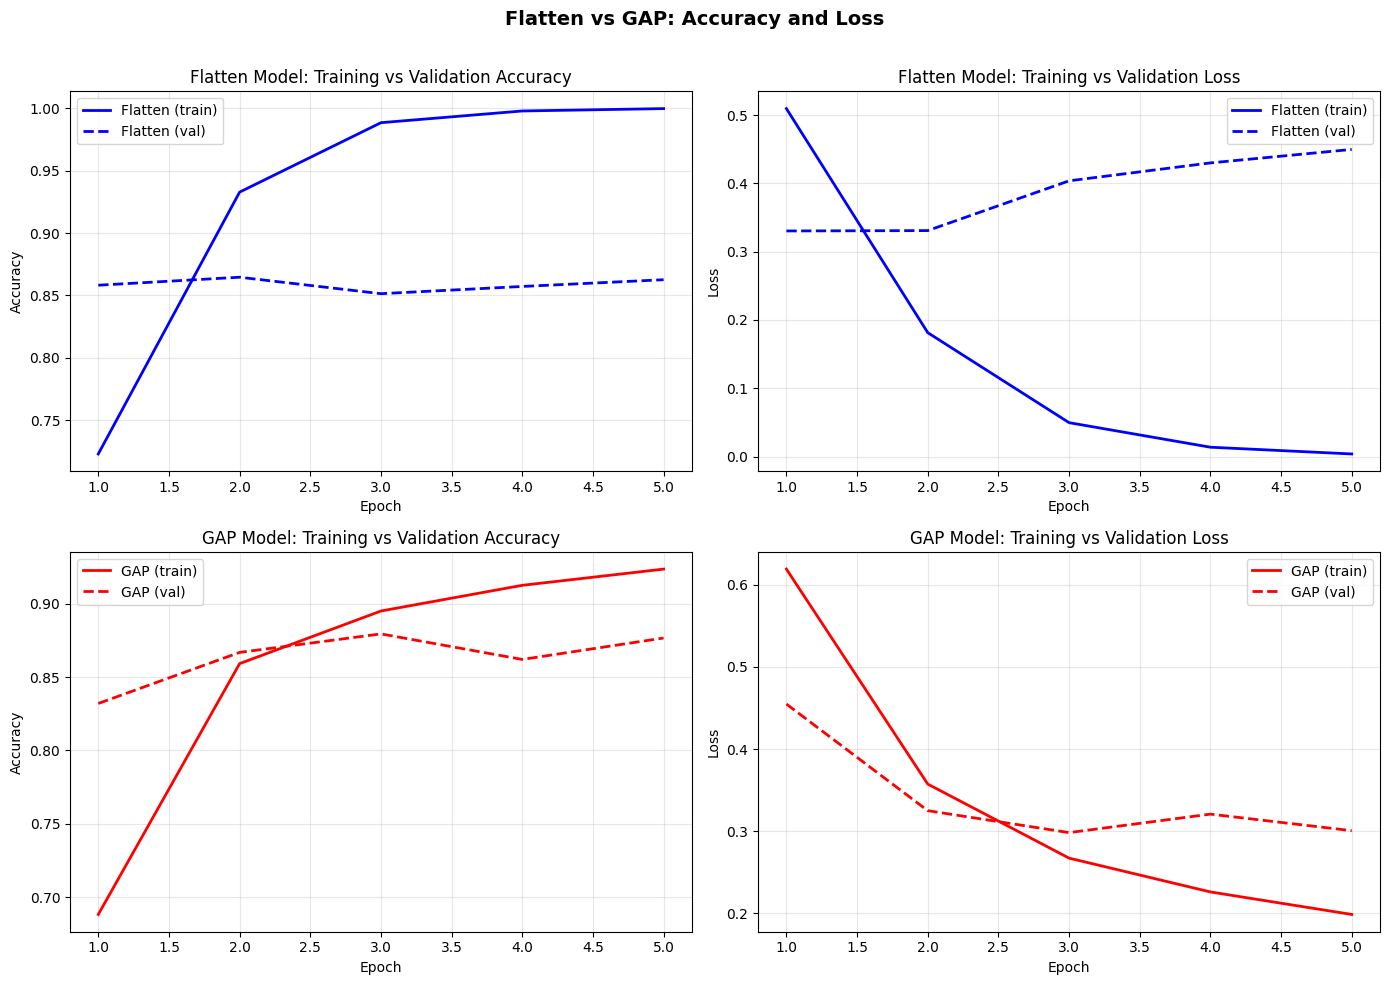

In [ ]:
epochs_flat = range(1, len(history_flatten.history['accuracy']) + 1) # Create a range for epochs for the Flatten model.
epochs_gap = range(1, len(history_gap.history['accuracy']) + 1) # Create a range for epochs for the GAP model.

fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # Create a figure and a 2x2 grid of subplots.

# 1) Flatten Accuracy (top-left)
ax = axes[0, 0]
ax.plot(epochs_flat, history_flatten.history['accuracy'], 'b-', label='Flatten (train)', linewidth=2) # Plot training accuracy for the Flatten model.
ax.plot(epochs_flat, history_flatten.history['val_accuracy'], 'b--', label='Flatten (val)', linewidth=2) # Plot validation accuracy for the Flatten model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Flatten Model: Training vs Validation Accuracy') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.

# 2) Flatten Loss (top-right)
ax = axes[0, 1]
ax.plot(epochs_flat, history_flatten.history['loss'], 'b-', label='Flatten (train)', linewidth=2) # Plot training loss for the Flatten model.
ax.plot(epochs_flat, history_flatten.history['val_loss'], 'b--', label='Flatten (val)', linewidth=2) # Plot validation loss for the Flatten model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Flatten Model: Training vs Validation Loss') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.

# 3) GAP Accuracy (bottom-left)
ax = axes[1, 0]
ax.plot(epochs_gap, history_gap.history['accuracy'], 'r-', label='GAP (train)', linewidth=2) # Plot training accuracy for the GAP model.
ax.plot(epochs_gap, history_gap.history['val_accuracy'], 'r--', label='GAP (val)', linewidth=2) # Plot validation accuracy for the GAP model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('GAP Model: Training vs Validation Accuracy') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.

# 4) GAP Loss (bottom-right)
ax = axes[1, 1]
ax.plot(epochs_gap, history_gap.history['loss'], 'r-', label='GAP (train)', linewidth=2) # Plot training loss for the GAP model.
ax.plot(epochs_gap, history_gap.history['val_loss'], 'r--', label='GAP (val)', linewidth=2) # Plot validation loss for the GAP model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GAP Model: Training vs Validation Loss') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.

plt.suptitle('Flatten vs GAP: Accuracy and Loss', fontsize=14, fontweight='bold') # Set a main title for the entire figure.
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust subplot parameters for a tight layout, preventing overlap.
plt.show() # Display the generated plots.

General Interpretation of Accuracy and Loss Curves:
Accuracy (Training vs. Validation):
Good Fit: If both training and validation accuracy increase over epochs and stay close to each other, the model is learning well and generalizing.
Overfitting: If training accuracy continues to increase while validation accuracy plateaus or starts to decrease, the model is overfitting. It's memorizing the training data but performing poorly on unseen data.
Underfitting: If both training and validation accuracy are low and don't improve much, the model is underfitting. It's not complex enough to capture the patterns in the data.
Loss (Training vs. Validation):
Good Fit: If both training and validation loss decrease over epochs and stay relatively close, the model is learning efficiently.
Overfitting: If training loss continues to decrease but validation loss starts to increase, the model is overfitting. Lower loss on training means better memorization, but higher validation loss indicates poor generalization.
Underfitting: If both training and validation loss remain high, the model is underfitting.
Insights from Your Specific Plots (Flatten vs. GAP):
Looking at the generated plots:

Flatten Model (Top Row):

Accuracy: The training accuracy for the Flatten model rapidly approaches 100%, while the validation accuracy peaks around 84-85% and then slightly fluctuates. This is a clear sign of overfitting. The model performs exceptionally well on the training data but struggles to generalize to new, unseen data, as indicated by the lower validation accuracy.
Loss: The training loss drops almost to zero, but the validation loss starts to increase after the first couple of epochs. This further confirms overfitting. The model is optimizing too much for the training set, leading to higher error on the validation set.
GAP Model (Bottom Row):

Accuracy: Both training and validation accuracy for the GAP model show a more consistent increase. Validation accuracy reaches around 86.5%, and while there's still a gap with training accuracy, it's less pronounced than the Flatten model. This suggests better generalization compared to the Flatten model.
Loss: Both training and validation loss decrease, with validation loss stabilizing at a reasonable level around 0.32. This indicates that the GAP model is learning more robust features and is less prone to memorizing the training data. There's still a slight divergence, but it's much better than the Flatten model's loss curve.
Conclusion:
Based on these plots, the GAP (GlobalAveragePooling1D) model appears to be performing better and generalizing more effectively on your IMDB dataset compared to the Flatten model. The Flatten model quickly overfits, demonstrating excellent performance on the training data but poor performance on the validation set. The GAP layer, by summarizing features across the sequence, likely helps in creating a more robust and less overfitted model for this task.

#Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer # Import the Tokenizer class for text preprocessing.
sample_reviews = [ # Define a list of sample movie reviews to demonstrate tokenization.
    "This movie was absolutely fantastic",
    "Terrible movie, waste of time",
    "The acting was fantastic and the plot was great",
    "I hated this movie so much",
    "A great movie with a wonderful story",
    "Worst movie I have ever seen",
]

In [ ]:
tokenizer = Tokenizer() # Initialize a Tokenizer object.

In [ ]:
tokenizer.fit_on_texts(sample_reviews) # Fit the Tokenizer on the `sample_reviews` to build the vocabulary (word-to-index mapping).

In [ ]:
tokenizer.word_index.items() # Display the word-to-index mapping learned by the tokenizer.

dict_items([('movie', 1), ('was', 2), ('this', 3), ('fantastic', 4), ('the', 5), ('great', 6), ('i', 7), ('a', 8), ('absolutely', 9), ('terrible', 10), ('waste', 11), ('of', 12), ('time', 13), ('acting', 14), ('and', 15), ('plot', 16), ('hated', 17), ('so', 18), ('much', 19), ('with', 20), ('wonderful', 21), ('story', 22), ('worst', 23), ('have', 24), ('ever', 25), ('seen', 26)])

In [ ]:
sequences = tokenizer.texts_to_sequences(sample_reviews) # Convert the sample reviews into sequences of integer indices based on the tokenizer's vocabulary.
sequences # Display the generated integer sequences.

[[3, 1, 2, 9, 4],
 [10, 1, 11, 12, 13],
 [5, 14, 2, 4, 15, 5, 16, 2, 6],
 [7, 17, 3, 1, 18, 19],
 [8, 6, 1, 20, 8, 21, 22],
 [23, 1, 7, 24, 25, 26]]

Padding

In [ ]:
padded = pad_sequences(sequences, maxlen=8, padding='pre') # Pad the integer sequences to a maximum length of 8, adding zeros at the beginning ('pre').
padded # Display the padded sequences.

array([[ 0,  0,  0,  3,  1,  2,  9,  4],
       [ 0,  0,  0, 10,  1, 11, 12, 13],
       [14,  2,  4, 15,  5, 16,  2,  6],
       [ 0,  0,  7, 17,  3,  1, 18, 19],
       [ 0,  8,  6,  1, 20,  8, 21, 22],
       [ 0,  0, 23,  1,  7, 24, 25, 26]], dtype=int32)

In [ ]:
vocab_size = len(tokenizer.word_index) + 1  # +1 because index 0 is reserved for padding
embedding_dim = 10  # Each word will be represented by a 4-dimensional vector


print(f"Vocabulary size: {vocab_size} (including padding token at index 0)")
print(f"Embedding dimension: {embedding_dim}")
print(f"Embedding matrix shape: ({vocab_size}, {embedding_dim})")
print()


# Create an embedding layer
embedding_layer = keras.layers.Embedding(
    input_dim=vocab_size,     # How many words in our vocabulary
    output_dim=embedding_dim  # How many dimensions per word vector
)


# Pass a single sequence through the embedding layer
sample_input = tf.constant([[1, 3, 5, 0]])  # "movie", "fantastic", "of",
embedded = embedding_layer(sample_input)

print(f"Input shape:  {sample_input.shape}  →  (1 sentence, 4 tokens)")
print(f"Output shape: {embedded.shape}  →  (1 sentence, 4 tokens, {embedding_dim}-dim vector each)")
print()
print("Each token is now a vector:")

Vocabulary size: 27 (including padding token at index 0)
Embedding dimension: 10
Embedding matrix shape: (27, 10)

Input shape:  (1, 4)  →  (1 sentence, 4 tokens)
Output shape: (1, 4, 10)  →  (1 sentence, 4 tokens, 10-dim vector each)

Each token is now a vector:


In [ ]:
x = tf.constant([[1,2],[3,4]], dtype=tf.float32)
y = tf.nn.softmax(x, axis=1)
print(y.numpy())

[[0.26894143 0.73105854]
 [0.26894143 0.73105854]]


In [ ]:
import numpy as np
def sigmoid(x):
  return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
  s = sigmoid(x)
  return s*(1-s)

def Relu(x):
  return np.maximum(0,x)

def Relu_derivative(x):
  d = Relu(x)
  return np.max(np.array(x)>0).astype(float)

#Dropput

In [ ]:
(x_train_fash, y_train_fash),(x_test_fash, y_test_fash) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
type(x_test_fash)

numpy.ndarray

In [ ]:
x_train_fash.shape

(60000, 28, 28)

In [ ]:
y_train_fash.shape

(60000,)

In [ ]:
x_train_fash=x_train_fash/255
x_test_fash=x_test_fash/255

In [ ]:
np.unique(y_test_fash)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
x_train_fash_flattend = tf.reshape(x_train_fash, [x_train_fash.shape[0],-1])
x_test_fash_flattend = tf.reshape(x_test_fash, [x_test_fash.shape[0],-1])
x_train_fash_flattend.shape

TensorShape([60000, 784])

In [ ]:
y_test_fash_one_hot = tf.one_hot(y_test_fash,10)
y_train_fash_one_hot = tf.one_hot(y_train_fash,10)

In [ ]:
y_train_fash_one_hot.shape

TensorShape([60000, 10])

In [ ]:
y_train_fash_one_hot[0]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)>

In [ ]:
model = keras.Sequential([
    #keras.layers.Flatten(input_shape=(28, 28)), # Input layer: flatten 28x28 images
    keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons and ReLU activation
    keras.layers.Dense(64, activation='relu'),   # Another hidden layer with 64 neurons and ReLU activation
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons (for 10 classes) and softmax activation
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Changed from sparse_categorical_crossentropy
    metrics=['accuracy']
)

# Display model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Train the model
history = model.fit(
    x_train_fash_flattend, y_train_fash_one_hot,
    epochs=10, # Number of training epochs
    validation_data=(x_test_fash_flattend, y_test_fash_one_hot) # Evaluate on test data after each epoch
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8258 - loss: 0.4879 - val_accuracy: 0.8435 - val_loss: 0.4334
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8659 - loss: 0.3663 - val_accuracy: 0.8554 - val_loss: 0.3859
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8779 - loss: 0.3295 - val_accuracy: 0.8681 - val_loss: 0.3640
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8856 - loss: 0.3076 - val_accuracy: 0.8708 - val_loss: 0.3534
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8911 - loss: 0.2940 - val_accuracy: 0.8677 - val_loss: 0.3578
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8960 - loss: 0.2774 - val_accuracy: 0.8739 - val_loss: 0.3475
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8990 - loss: 0.2669 - val_accuracy: 0.8756 - val_loss: 0.3404
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9041 - loss: 0.2544 - 

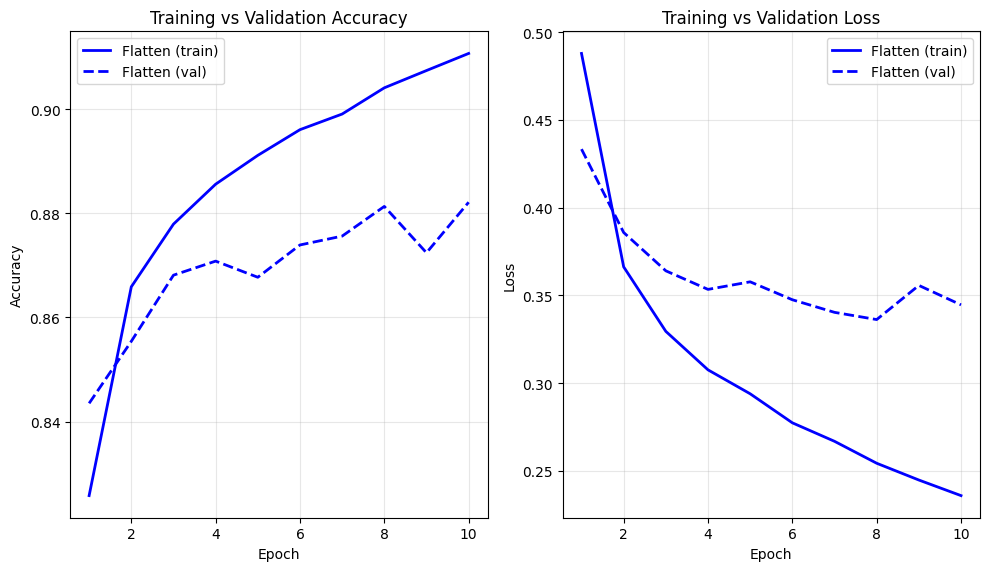

In [ ]:
epochs_flat = range(1, len(history.history['accuracy']) + 1) # Create a range for epochs for the Flatten model.


fig, axes = plt.subplots(1, 2, figsize=(10, 6)) # Create a figure and a 2x2 grid of subplots.

# 1) Flatten Accuracy (top-left)
ax = axes[0]
ax.plot(epochs_flat, history.history['accuracy'], 'b-', label='Flatten (train)', linewidth=2) # Plot training accuracy for the Flatten model.
ax.plot(epochs_flat, history.history['val_accuracy'], 'b--', label='Flatten (val)', linewidth=2) # Plot validation accuracy for the Flatten model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Validation Accuracy') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.

# 2) Flatten Loss (top-right)
ax = axes[1]
ax.plot(epochs_flat, history.history['loss'], 'b-', label='Flatten (train)', linewidth=2) # Plot training loss for the Flatten model.
ax.plot(epochs_flat, history.history['val_loss'], 'b--', label='Flatten (val)', linewidth=2) # Plot validation loss for the Flatten model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust subplot parameters for a tight layout, preventing overlap.
plt.show() # Display the generated plots.

#Using dropout to address overfitting issue

In [ ]:
model_wt_drpout = keras.Sequential([
    #keras.layers.Flatten(input_shape=(28, 28)), # Input layer: flatten 28x28 images
    keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons and ReLU activation
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),   # Another hidden layer with 64 neurons and ReLU activation
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons (for 10 classes) and softmax activation
])

# Compile the model
model_wt_drpout.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Changed from sparse_categorical_crossentropy
    metrics=['accuracy']
)

# Display model summary
model_wt_drpout.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Train the model
history_wt_drpout = model_wt_drpout.fit(
    x_train_fash_flattend, y_train_fash_one_hot,
    epochs=10, # Number of training epochs
    validation_data=(x_test_fash_flattend, y_test_fash_one_hot) # Evaluate on test data after each epoch
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7743 - loss: 0.6343 - val_accuracy: 0.8268 - val_loss: 0.4734
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8345 - loss: 0.4660 - val_accuracy: 0.8461 - val_loss: 0.4197
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8456 - loss: 0.4272 - val_accuracy: 0.8517 - val_loss: 0.4080
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8527 - loss: 0.4090 - val_accuracy: 0.8647 - val_loss: 0.3797
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8588 - loss: 0.3895 - val_accuracy: 0.8675 - val_loss: 0.3685
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8637 - loss: 0.3746 - val_accuracy: 0.8665 - val_loss: 0.3707
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8677 - loss: 0.3633 - val_accuracy: 0.8712 - val_loss: 0.3658
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8705 - loss: 0.3569 -

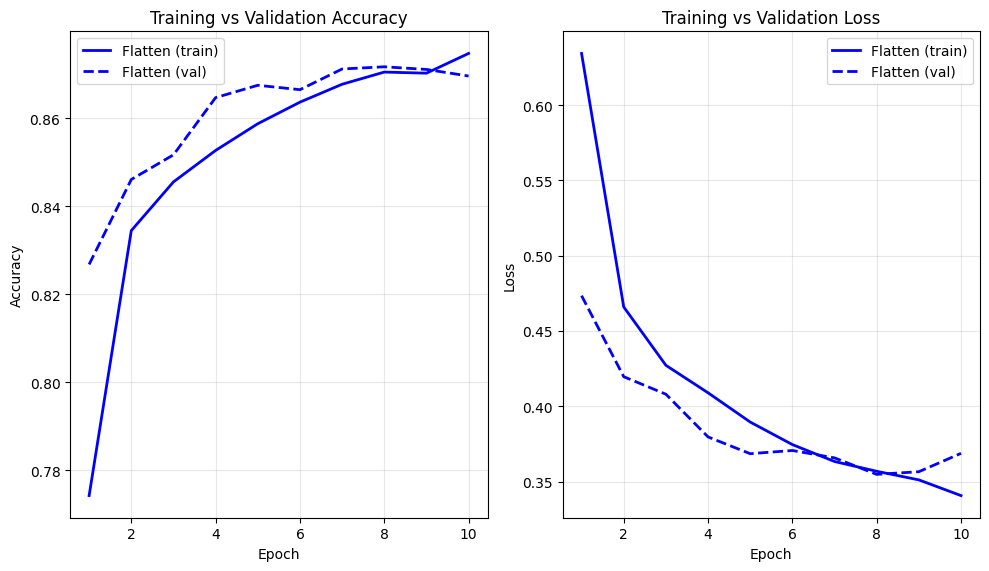

In [ ]:
epochs_flat = range(1, len(history_wt_drpout.history['accuracy']) + 1) # Create a range for epochs for the Flatten model.


fig, axes = plt.subplots(1, 2, figsize=(10, 6)) # Create a figure and a 2x2 grid of subplots.

# 1) Flatten Accuracy (top-left)
ax = axes[0]
ax.plot(epochs_flat, history_wt_drpout.history['accuracy'], 'b-', label='Flatten (train)', linewidth=2) # Plot training accuracy for the Flatten model.
ax.plot(epochs_flat, history_wt_drpout.history['val_accuracy'], 'b--', label='Flatten (val)', linewidth=2) # Plot validation accuracy for the Flatten model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Validation Accuracy') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.

# 2) Flatten Loss (top-right)
ax = axes[1]
ax.plot(epochs_flat, history_wt_drpout.history['loss'], 'b-', label='Flatten (train)', linewidth=2) # Plot training loss for the Flatten model.
ax.plot(epochs_flat, history_wt_drpout.history['val_loss'], 'b--', label='Flatten (val)', linewidth=2) # Plot validation loss for the Flatten model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust subplot parameters for a tight layout, preventing overlap.
plt.show() # Display the generated plots.

#Model with early stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

In [ ]:
# Train the model
history_wt_drpout_earlystopping = model_wt_drpout.fit(
    x_train_fash_flattend, y_train_fash_one_hot,
    epochs=10, # Number of training epochs
    callbacks=[early_stop],
    validation_data=(x_test_fash_flattend, y_test_fash_one_hot) # Evaluate on test data after each epoch
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8838 - loss: 0.3158 - val_accuracy: 0.8760 - val_loss: 0.3506
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8855 - loss: 0.3113 - val_accuracy: 0.8795 - val_loss: 0.3349
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8857 - loss: 0.3074 - val_accuracy: 0.8789 - val_loss: 0.3433
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8865 - loss: 0.3084 - val_accuracy: 0.8793 - val_loss: 0.3441
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8873 - loss: 0.3021 - val_accuracy: 0.8743 - val_loss: 0.3614
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8894 - loss: 0.3005 - val_accuracy: 0.8835 - val_loss: 0.3412


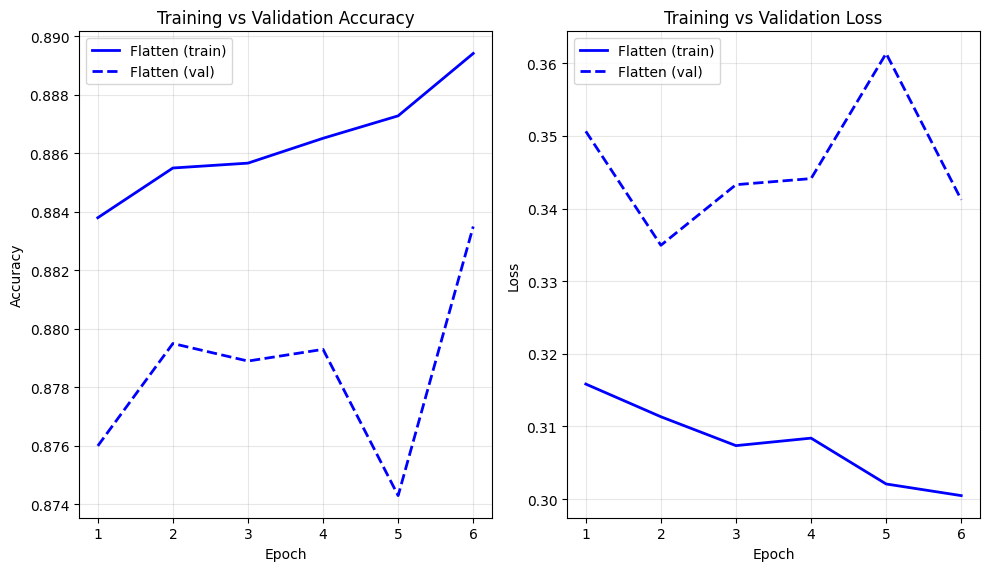

In [ ]:
epochs_flat = range(1, len(history_wt_drpout_earlystopping.history['accuracy']) + 1) # Create a range for epochs for the Flatten model.


fig, axes = plt.subplots(1, 2, figsize=(10, 6)) # Create a figure and a 2x2 grid of subplots.

# 1) Flatten Accuracy (top-left)
ax = axes[0]
ax.plot(epochs_flat, history_wt_drpout_earlystopping.history['accuracy'], 'b-', label='Flatten (train)', linewidth=2) # Plot training accuracy for the Flatten model.
ax.plot(epochs_flat, history_wt_drpout_earlystopping.history['val_accuracy'], 'b--', label='Flatten (val)', linewidth=2) # Plot validation accuracy for the Flatten model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Validation Accuracy') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.

# 2) Flatten Loss (top-right)
ax = axes[1]
ax.plot(epochs_flat, history_wt_drpout_earlystopping.history['loss'], 'b-', label='Flatten (train)', linewidth=2) # Plot training loss for the Flatten model.
ax.plot(epochs_flat, history_wt_drpout_earlystopping.history['val_loss'], 'b--', label='Flatten (val)', linewidth=2) # Plot validation loss for the Flatten model.
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss') # Set title for the plot.
ax.legend() # Display legend.
ax.grid(True, alpha=0.3) # Add a grid.
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust subplot parameters for a tight layout, preventing overlap.
plt.show() # Display the generated plots.